# [PBT] 화장품 이커머스 ㅣ 10. 이변량 — A조 · 탐색 행동 4종 〈이슬기〉

## 이 노트북이 하는 일

EDA **STEP 3 이변량**
묻는 것 : **종속을 설명하는가** (채택 근거 ① 관련성 · ② 효과크기)

```
연속형 3 : prior_view_cnt · prior_uniq_product_cnt · cart_product_view_cnt
이진   1 : has_prior_view
```
**만든 사람이 아닌 쪽이 분석해야 설계 단계에서 놓친 것이 드러난다**(설계 §4-2).

## 여기서 하지 않는 것

| 안 하는 것 | 어디서 |
|---|---|
| **다변량 · VIF · 변수 선택** | **`11` — 둘이 함께.** 나눌 수 없다(설계 §4-1) |
| 스코어카드 판정 | `11` — 둘이 함께 |
| 로그변환 실행 | ⑤ 전처리, 층화 분할 후 |
| B조 4종 | `10b` (배지환) |

> **셋 중 무엇을 남길지 여기서 정하지 않는다.** `prior_view_cnt`·`prior_uniq_product_cnt`·`has_prior_view`는
> 서로 얽혀 있고, 그 판정은 **다변량(`11`)의 일**이다. 여기서는 **각각이 Y를 설명하는지만** 본다.

## 진입 전 확정된 것 — 설계 §7 검토 포인트 ①·④

### ① 연속형 X의 효과크기 → **`anova_oneway`의 `np2`를 쓴다**

우리 조합(연속 X ↔ 이진 Y)에는 딱 맞는 표준 효과크기 지표가 정해져 있지 않다.
**그래서 분석 도구로 직접 채운다.**

| 확인 | 근거 |
|---|---|
| `anova_oneway`가 2집단에서 돌고 `np2`를 반환한다 | 설계 §2-3 (가짜 데이터로 확인) |
| 기준선 0.01 / 0.06 / 0.14 | Cohen(1988) 관례 |
| 정규성 미충족인데 ANOVA를 써도 되는가 | CLT 덕에 ANOVA는 정규성에 비교적 강건 (★ 약함) |
| 표본 불균형(22,236 vs 86,222) | `welch_anova` 자동 분기 (★★) |

**비우지 않고 채운 이유** — 설계 §3-3에 따라 **효과크기로 변수를 자르지 않으므로 판정이 달라지지 않는다.**
채워도 규율 위험이 없고, 비우면 결과표의 연속형 칸만 빈칸이 되어 보고서가 읽히지 않는다.

> **대가** — 이진 Y에는 T검정 계열을 주 검정으로 두고, ANOVA 계열 도구는 **효과크기 목적으로만 함께** 쓴다.
> **보고서에 한 문장으로 밝힌다.** **주 검정은 `test_independent`**이고 p값·검정명은 거기서 가져온다.

### ④ 유의성의 용도 → **보고하되 자르지 않는다**

채택근거 ①(관련성)은 `p < α`다. 확인하고 보고하되 **변별에는 쓰지 않는다.**
표본이 커서 사소한 차이도 유의하게 나오기 때문이다(설계 §3-3).

## 📐 수치 표기 규칙 (설계 §4-5)

> 판정문의 모든 수치에 **어느 셀에서 나오는지**를 `#03-1` 형태로 적는다.
> 외부 문서 인용은 출처를 밝힌다. **둘 다 아닌 수치는 쓰지 않는다.**

---

## #01. 준비

In [2]:
import os, sys

# 프로젝트 폴더 — notebooks/ 안에서 실행하면 상위 폴더를 가리킨다
from pathlib import Path
BASE = str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())
os.chdir(BASE)
sys.path.insert(0, BASE)

from numpy import sqrt, abs as np_abs, where
from pandas import read_csv, to_datetime, DataFrame, Series, crosstab, set_option
from scipy.stats import chi2_contingency
from helpers import my_stats, my_prep, my_plot

set_option("display.max_columns", 50)
set_option("display.max_colwidth", 60)

OUT = BASE + r"\output"
ALPHA = 0.05
print("데이터 폴더 :", OUT)

데이터 폴더 : .\output


### 1-1. 마스터 테이블 + 08번 대조 — 하나라도 어긋나면 멈춘다

In [3]:
m = read_csv(OUT + r"\03_master.csv", encoding="utf-8-sig")

m["t0"]          = to_datetime(m["t0"], format="%Y-%m-%d %H:%M:%S")
m["product_id"]  = m["product_id"].astype("int32")
m["purchase_7d"] = m["purchase_7d"].astype("int8")
m["cart_timeband"] = m["cart_timeband"].astype("category").cat.set_categories(
    ["심야", "오전", "오후", "저녁"], ordered=True)
m["cart_weekday"]  = m["cart_weekday"].astype("category").cat.set_categories(
    ["월", "화", "수", "목", "금", "토", "일"], ordered=True)
for c in ["brand_grp", "category_grp"]:
    m[c] = m[c].astype("category")

# test_independent 는 wide 를 요구한다 (설계 §2-2 함정 ①). 라벨을 미리 만들어 둔다.
m["Y라벨"] = where(m["purchase_7d"] == 1, "구매", "미구매")

ok = [("행 수", f"{len(m):,}", "108,458"),
      ("1행 = 1고객", str(len(m) == m["user_id"].nunique()), "True"),
      ("Y 양성", f"{int(m['purchase_7d'].sum()):,}명 / {m['purchase_7d'].mean():.2%}", "22,236명 / 20.50%"),
      ("brand_grp", f"{m['brand_grp'].nunique()}종", "15종")]
chk = DataFrame(ok, columns=["항목", "이번 실행", "08번 값"])
chk["일치"] = chk["이번 실행"] == chk["08번 값"]
chk

,항목,이번 실행,08번 값,일치
0,행 수,"108,458","108,458",True
1,1행 = 1고객,True,True,True
2,Y 양성,"22,236명 / 20.50%","22,236명 / 20.50%",True
3,brand_grp,15종,15종,True


In [4]:
def _p(x):
    "함수가 소수 4자리로 반올림해 0.0 으로 찍는다. 보고서에 p = 0.0 이라고 쓰지 않는다 (설계 §3-1)."
    return "< 0.0001" if x < 0.0001 else f"{x:.4f}"


def cont_test(col):
    "연속형 X ↔ 이진 Y. 주 검정 + 효과크기를 한 번에."
    w = my_prep.long2wide(m[[col, "Y라벨"]], hue="Y라벨", values=col)
    r = my_stats.test_independent(w, "구매", "미구매", plot=False)
    two = r.xs("two-sided", level="alternative")
    a = my_stats.anova_oneway(m[[col, "purchase_7d"]], y=col, between="purchase_7d")
    g = m.groupby("Y라벨", observed=True)[col].mean()
    return {"변수": col,
            "검정": r.index.get_level_values("test")[0],
            "p": float(two["p-value"].iloc[0]),
            "ANOVA": str(a["test"].iloc[0]),
            "np2": round(float(a["np2"].iloc[0]), 5),
            "효과크기 라벨": str(a["effect_size"].iloc[0]),
            "구매 평균": round(g["구매"], 4), "미구매 평균": round(g["미구매"], 4)}


def nomi_test(col):
    "명목·이진 X ↔ 이진 Y. 교차분석."
    d = my_stats.chi2_independence(m, col, "purchase_7d", plot=False).iloc[0]
    return {"변수": col, "검정": str(d["test"]),
            "chi2": round(float(d["chi2"]), 3), "dof": int(d["dof"]),
            "p": float(d["p-value"]), "V": round(float(d["effect(V)"]), 4),
            "strength": str(d["strength"]),
            "min_expected": round(float(d["min_expected"]), 1),
            "가정 충족": bool(d["assumption"])}


def rate_by(col):
    "범주별 Y 비율 — 교차표에 행 기준 비율을 붙여 읽는 서술 도구."
    g = m.groupby(col, observed=True)["purchase_7d"]
    return DataFrame({"고객 수": g.size(), "Y 비율(%)": (g.mean() * 100).round(2)})


print("공용 함수 4개 준비 완료 — cont_test · nomi_test · rate_by · _p")
print(f"전체 평균 Y 비율 : {m['purchase_7d'].mean() * 100:.2f}%")

공용 함수 4개 준비 완료 — cont_test · nomi_test · rate_by · _p
전체 평균 Y 비율 : 20.50%


---

## #02. 연속형 3종 — `test_independent` + `anova_oneway`

| 무엇을 | 어디서 |
|---|---|
| 검정명 · p값 | `test_independent` — 이진 Y ↔ 연속 X의 주 검정 |
| 효과크기 `np2` | `anova_oneway` — 기준선 0.01 / 0.06 / 0.14 (Cohen 1988) |

In [5]:
A_CONT = ["prior_view_cnt", "prior_uniq_product_cnt", "cart_product_view_cnt"]

A_CONT_R = DataFrame([cont_test(c) for c in A_CONT]).set_index("변수")
A_CONT_R

,검정,p,ANOVA,np2,효과크기 라벨,구매 평균,미구매 평균
변수,,,,,,,
prior_view_cnt,Mann-Whitney U test,0.0,welch_anova,0.00100,Negligible,1.4262,1.2420
prior_uniq_product_cnt,Mann-Whitney U test,0.0,welch_anova,0.00073,Negligible,1.2258,1.0926
cart_product_view_cnt,Mann-Whitney U test,0.0,welch_anova,0.00776,Negligible,0.5725,0.4289


> **`p = 0.0`으로 찍히면 반올림 결과다.** 보고서에는 **`p < 0.0001`**로 적는다(설계 §3-1).
>
> **Mann-Whitney U가 나왔다면 예상대로다** — n = 108,458이라 `normaltest`가 사실상 항상 기각한다(설계 §2-2 함정 ②).
> 보고서에는 *"정규성이 충족되지 않아 Mann-Whitney U가 자동 적용되었다"*로 적는다.

### 2-1. 그림 — 그룹별 박스플롯

명목(2) × 연속 조합에는 박스플롯을 쓴다.

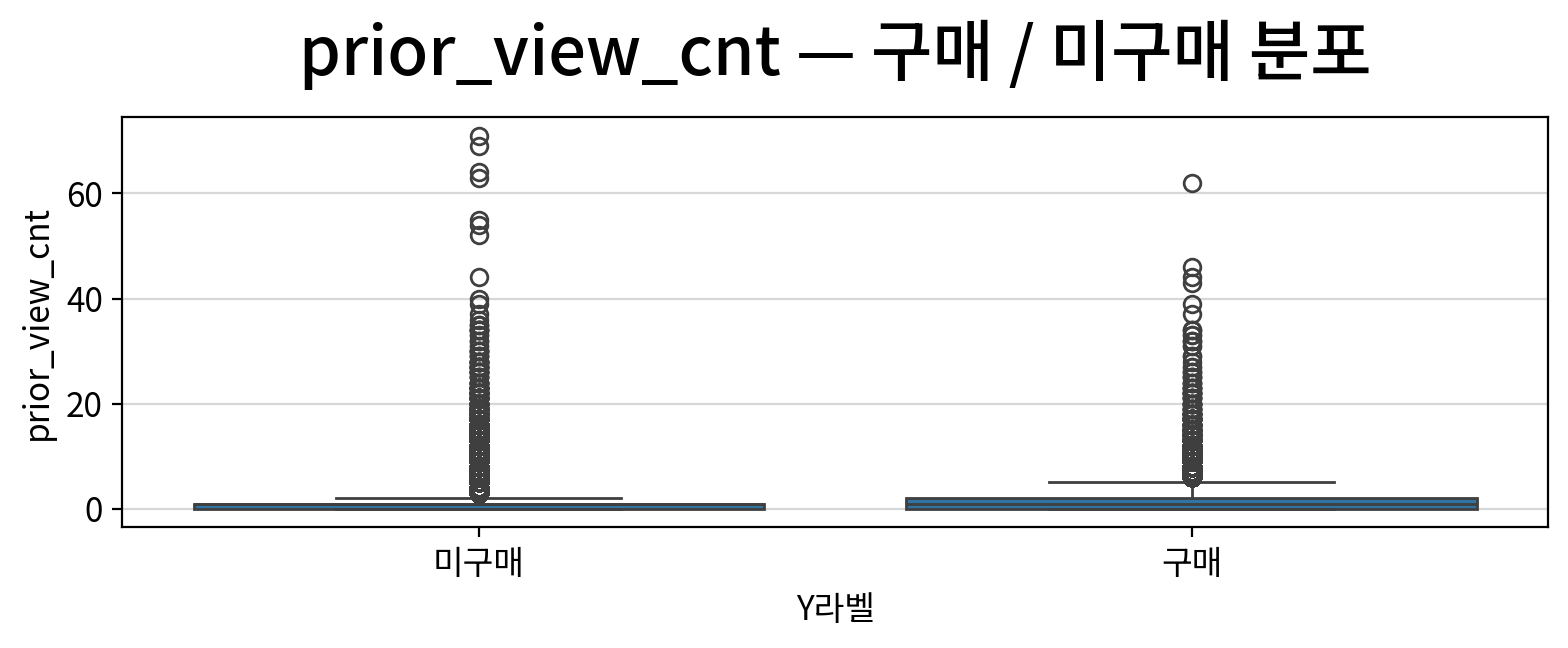

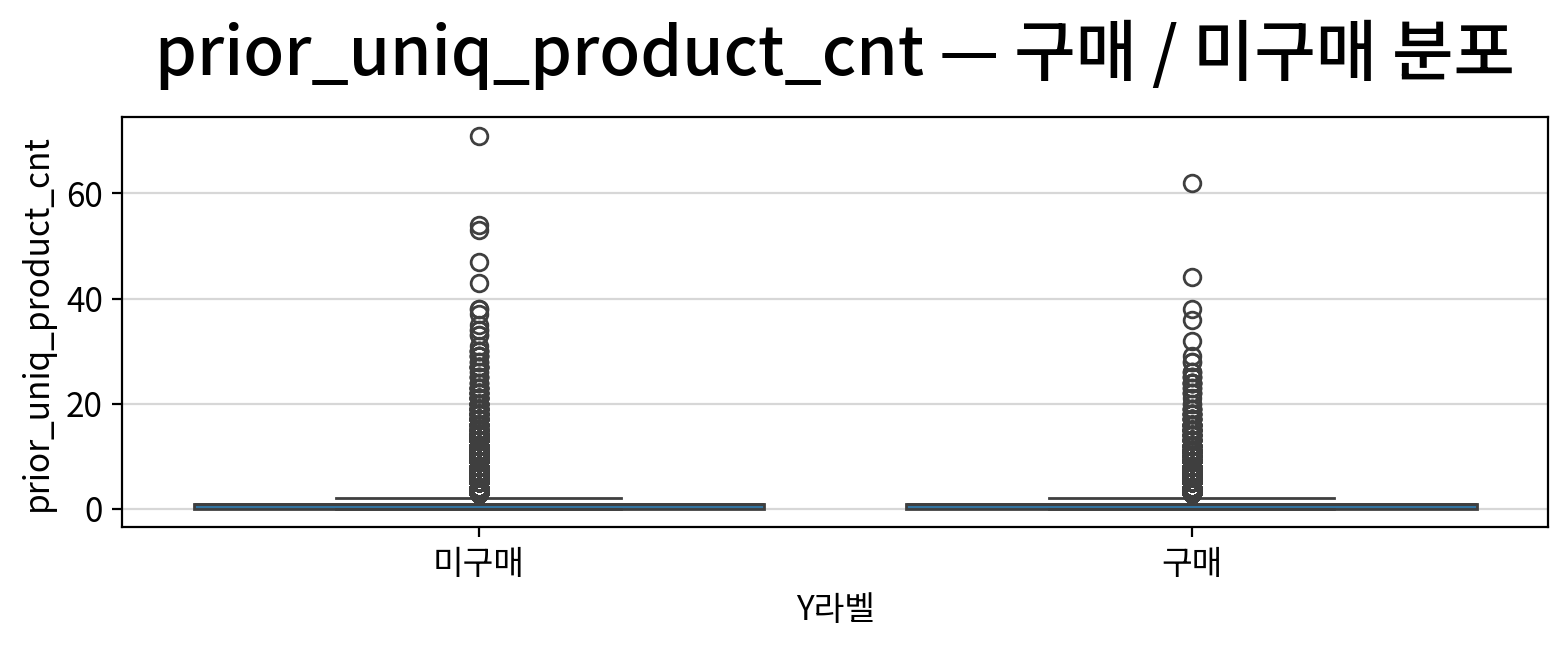

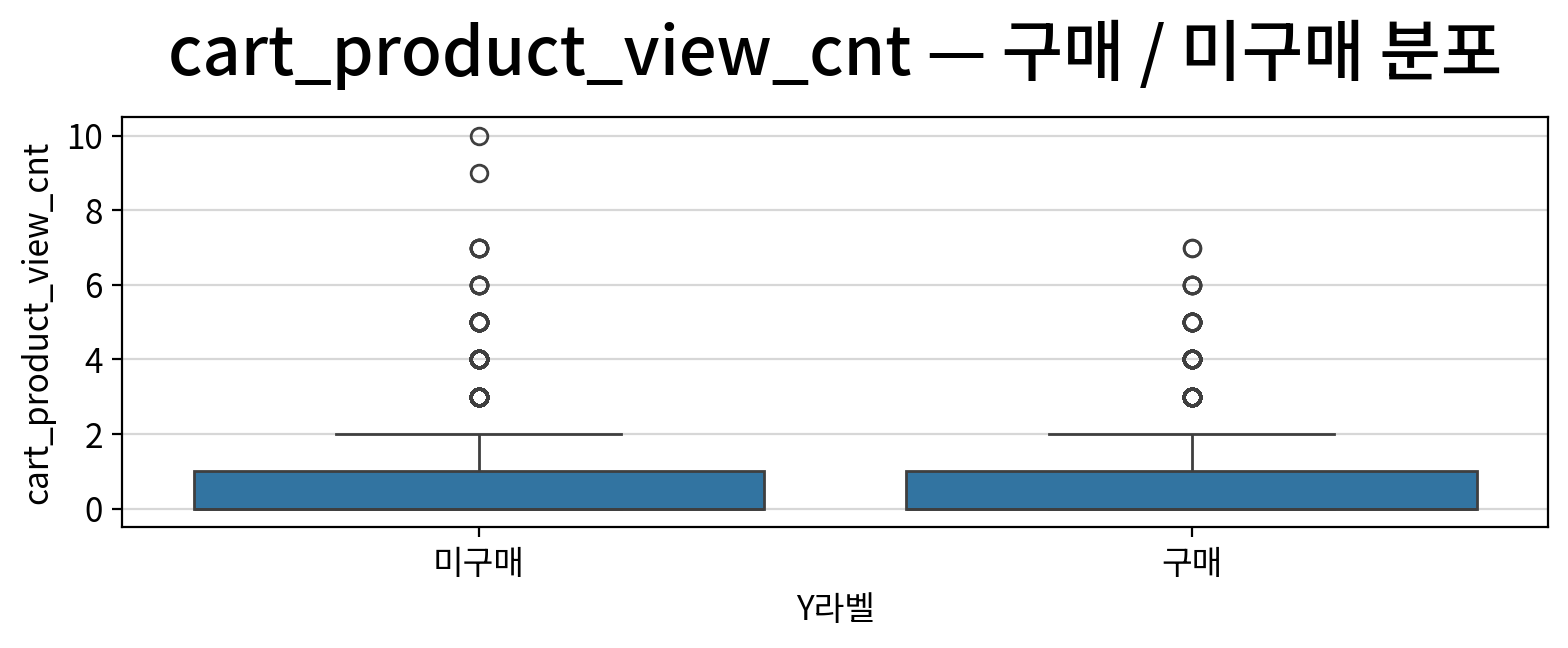

In [6]:
for c in A_CONT:
    my_plot.boxplot(data=m, x="Y라벨", y=c,
                    title=f"{c} — 구매 / 미구매 분포", width=800, height=340)

---

## #03. 이진 1종 `has_prior_view` — 교차분석

이진 X ↔ 이진 Y는 **2×2 교차분석**이다.

In [7]:
A_NOMI_R = DataFrame([nomi_test("has_prior_view")]).set_index("변수")
A_NOMI_R

,검정,chi2,dof,p,V,strength,min_expected,가정 충족
변수,,,,,,,,
has_prior_view,Chi-square test of independence,207.049,1,0.0,0.0437,Negligible,9934.6,True


> **`strength` 라벨은 판정에 쓰지 않는다**(설계 §3-3·§3-7).
> 코드의 4구간 라벨(`Negligible` 포함)은 관례적 분류일 뿐이고, Cramér's V의 해석 기준선은 널리 합의된 출처가 없다.
> (η²ₚ·Hedges' g는 Cohen(1988) 기준을 따르지만 V는 그렇지 않다.)
>
> ⚠️ **`min_expected`를 반드시 확인한다.** Fisher 자동 전환은 **2×2에서만** 일어난다(설계 §2-2 함정 ⑤).

### 3-1. 범주별 Y 비율

교차표에 **행 기준 비율 열**을 붙여 범주별 구매율을 직접 비교한다.

In [8]:
rate_by("has_prior_view")

,고객 수,Y 비율(%)
has_prior_view,,
0,48457,18.54
1,60001,22.09


---

## #04. A조 판정표 — **직접 채운다**

이 표의 관찰 서술과 조치 판단은 분석가가 쓴다. 컬럼 구조는 09번 단변량 판정표와 맞췄다.

**표 머리 단서 두 줄** :
> *"채택 기준은 **'각 독립변수 → 종속변수 단독 관계'만** 사용한다."*
> *"**공선성(변수 간 중복)은 이 이변량 단계에서는 알 수 없다.**"*

수치 출처 — `#02`(연속형 결과표 `A_CONT_R`) · `#03`(이진 결과표 `A_NOMI_R`) · `#03-1`(범주별 Y 비율).
전체 고객 108,458명, 전체 구매율 20.50%.

---

### `prior_view_cnt` — 장바구니 담기 전 상품 조회 횟수

| 항목 | 관찰 내용 |
|---|---|
| 검정 · p | Mann-Whitney U test · **p < 0.0001** → 유의 (`#02`) |
| 효과크기 np2 | **0.00100** — 0.01 미만, 미미 구간 (welch-ANOVA, `#02`) |
| 방향 (구매/미구매 평균) | 구매 **1.4262** > 미구매 **1.2420**. 구매 그룹이 담기 전 더 많이 조회함. 단 중앙값은 양쪽 모두 1.0 — 차이는 상위 꼬리(다량 조회 고객)에서 발생 (`#02`) |
| 가정점검 | 정규성 미충족(n=108,458) → Mann-Whitney U 자동. 등분산 미충족 → welch-ANOVA 자동 분기. 표본 불균형 22,236 vs 86,222 |

**소견** : 방향은 "담기 전 조회가 많을수록 구매"로 상식과 일치하고 p도 유의하다. 
그러나 효과크기가 미미하고 중앙값이 같아 단독 설명력은 약하다. 
`prior_uniq_product_cnt`와 방향·유의성·효과크기가 거의 동일해 둘이 겹칠 가능성이 크다 — 무엇을 남길지는 `11`.

---

### `prior_uniq_product_cnt` — 담기 전 조회한 고유 상품 수

| 항목 | 관찰 내용 |
|---|---|
| 검정 · p | Mann-Whitney U test · **p < 0.0001** → 유의 (`#02`) |
| 효과크기 np2 | **0.00073** — A조 세 연속변수 중 가장 작음 (welch-ANOVA, `#02`) |
| 방향 | 구매 **1.2258** > 미구매 **1.0926**. 중앙값은 양쪽 모두 1.0 (`#02`) |
| 가정점검 | `prior_view_cnt`와 동일 — 정규성·등분산 모두 미충족, 비모수·welch 자동 적용 |

**소견** : `prior_view_cnt`와 방향·유의성·효과크기가 사실상 같다. 

단독으로는 Y를 거의 설명하지 못한다. `prior_view_cnt`와의 중복 여부는 `11`에서 확인.

---

### `cart_product_view_cnt` — 장바구니에 담은 상품의 조회 횟수

| 항목 | 관찰 내용 |
|---|---|
| 검정 · p | Mann-Whitney U test · **p < 0.0001** → 유의 (`#02`) |
| 효과크기 np2 | **0.00776** — 여전히 0.01 미만이나 A조 세 연속변수 중 가장 큼 (welch-ANOVA, `#02`) |
| 방향 | 구매 **0.5725** > 미구매 **0.4289**. 중앙값은 양쪽 모두 0.0 (`#02`) |
| 가정점검 | 정규성·등분산 미충족 → 비모수·welch 자동 적용 |

**소견** : 세 연속변수 중 구매/미구매 평균 격차(약 0.14회, 상대적으로 +33%)와 효과크기가 가장 크다. 
담은 상품을 반복해서 들여다본 행동이 구매와 가장 가깝게 붙어 있다. 
앞의 두 변수(담기 *전* 행동)와 성격이 달라 중복 위험도 상대적으로 낮아 보인다 — 확정은 `11`.

---

### `has_prior_view` — 담기 전 조회 여부 (0/1)

| 항목 | 관찰 내용 |
|---|---|
| 검정 · χ² · dof · p | Chi-square test of independence · χ² = **207.049** · dof = **1** · **p < 0.0001** → 유의 (`#03`) |
| 효과크기 V | Cramér's V = **0.0437** — 미미 구간 (`#03`) |
| 범주별 Y 비율 | 미조회(0) **18.54%** (48,457명) vs 조회(1) **22.09%** (60,001명) — 두 집단 격차 **3.55%p** (`#03-1`) |
| 가정점검 (min_expected) | 최소 기대빈도 **9,934.6** ≫ 5 → 카이제곱 가정 충족. 2×2이지만 Fisher 전환 조건 아님 |

**소견** : 사전 조회를 "했는가"라는 이분 정보만으로도 구매율이 3.55%p 갈린다. 
방향은 조회변수들과 일치한다. 효과크기는 미미하고, 조회 횟수가 1 이상이면 곧 `has_prior_view=1`이므로 `prior_view_cnt`·`prior_uniq_product_cnt`와 정보가 겹친다. 
횟수 변수와 이진 변수 중 무엇을 남길지는 `11` 다변량의 판단이다.

---

> **"소견"이라고 쓴 이유** — 채택/보류/제외 **판정은 `10c`에서 A·B 결과를 함께 놓고** 내린다.
> 여기서는 *"이 변수가 Y를 단독으로 설명하는가"*에 대한 관찰만 적는다.
> **네 변수 모두** p는 유의하나 효과크기는 미미 구간이다. **유의성으로도 효과크기로도 여기서 변수를 자르지 않는다**(설계 §3-3·④).

## #05. A조 결과표 — 전달용

수치는 코드가 만들고, `소견`만 `#04`에서 옮겨 적는다.

In [ ]:
rows = []
for v, r in A_CONT_R.iterrows():
    rows.append({"담당": "A · 이슬기", "변수": v, "척도": "연속",
                 "검정방법": r["검정"], "p": _p(r["p"]), "유의": r["p"] < ALPHA,
                 "효과크기": f"np2 = {r['np2']:.5f}", "효과크기값": r["np2"],
                 "가정점검": "정규성 미충족 → 비모수 자동 적용"})
for v, r in A_NOMI_R.iterrows():
    rows.append({"담당": "A · 이슬기", "변수": v, "척도": "이진",
                 "검정방법": r["검정"], "p": _p(r["p"]), "유의": r["p"] < ALPHA,
                 "효과크기": f"V = {r['V']:.4f}", "효과크기값": r["V"],
                 "가정점검": f"기대빈도 최소 {r['min_expected']:,.1f} · 가정 {'충족' if r['가정 충족'] else '★위배'}"})

A_BIV = DataFrame(rows).set_index("변수")

# 소견은 사람이 적는다 (#04 에서 옮김). 키가 빠지면 KeyError 로 즉시 터진다.
OPINION = {
    "prior_view_cnt":         "방향 일치(구매 1.4262 > 미구매 1.2420), p 유의하나 np2 0.00100로 미미. prior_uniq_product_cnt와 패턴 동일 — 중복은 11에서.",
    "prior_uniq_product_cnt": "prior_view_cnt와 방향·유의성·효과크기 사실상 동일. 세 연속변수 중 np2 최소(0.00073). 단독 설명력 약함.",
    "cart_product_view_cnt":  "세 연속변수 중 평균 격차(+33%)·np2(0.00776) 최대. 담긴 상품 반복 조회가 구매와 가장 근접. 담기 전 변수들과 성격 달라 중복 위험 낮음.",
    "has_prior_view":         "조회 여부만으로 구매율 18.54% → 22.09%(격차 3.55%p). χ²=207.049, p 유의, V 0.0437 미미. 조회 횟수 변수들과 정보 중복.",
}
A_BIV["소견"] = [OPINION[i] for i in A_BIV.index]

A_BIV

,담당,척도,검정방법,p,유의,효과크기,효과크기값,가정점검,소견
변수,,,,,,,,,
prior_view_cnt,A · 이슬기,연속,Mann-Whitney U test,< 0.0001,True,np2 = 0.00100,0.00100,정규성 미충족 → 비모수 자동 적용,"방향 일치(구매 1.4262 > 미구매 1.2420), p 유의하나 np2 0.00100로 미미. p..."
prior_uniq_product_cnt,A · 이슬기,연속,Mann-Whitney U test,< 0.0001,True,np2 = 0.00073,0.00073,정규성 미충족 → 비모수 자동 적용,prior_view_cnt와 방향·유의성·효과크기 사실상 동일. 세 연속변수 중 np2 최소(0.00...
cart_product_view_cnt,A · 이슬기,연속,Mann-Whitney U test,< 0.0001,True,np2 = 0.00776,0.00776,정규성 미충족 → 비모수 자동 적용,세 연속변수 중 평균 격차(+33%)·np2(0.00776) 최대. 담긴 상품 반복 조회가 구매와 가...
has_prior_view,A · 이슬기,이진,Chi-square test of independence,< 0.0001,True,V = 0.0437,0.04370,"기대빈도 최소 9,934.6 · 가정 충족","조회 여부만으로 구매율 18.54% → 22.09%(격차 3.55%p). χ²=207.049, p 유..."


In [10]:
A_PATH = OUT + r"\10a_이변량_A조.csv"
A_BIV.to_csv(A_PATH, encoding="utf-8-sig")
print("저장 완료 :", A_PATH)
print(f"  {A_BIV.shape[0]}행 × {A_BIV.shape[1]}열")

저장 완료 : .\output\10a_이변량_A조.csv
  4행 × 9열


---

## #06. 다음

| 할 일 | 누가 |
|---|---|
| `#04` 소견 4개 확인 후 `#05` 재저장 | 이슬기 |
| `10a_이변량_A조.csv` 전달 | 이슬기 → 배지환 |
| **A·B 결과를 함께 읽는다** | 둘이 함께 |
| **`11` 다변량 + 스코어카드** | **둘이 함께** — 나눌 수 없다 |

> **아직 하지 않은 것** — 셋 중 무엇을 남길지. VIF는 X 집합 전체에서 나오고
> 변수 하나를 빼면 나머지 전부가 재산정된다. **`11`의 일이다.**